## Setup

`.env` must contain the following values:
```
SERVER_IP=your_server_ip
FTP_PORT=21
FTP_USER=your_username
FTP_PASSWORD=your_password
```

Use the same `.venv` you use for dev here with python >= 3.12.10

In [8]:
from ftplib import FTP
from pathlib import Path
from dotenv import load_dotenv
import os

# --- LOAD ENV ---
BASE_DIR = Path().resolve().parents[2] / "Internomat"
env_path = BASE_DIR / ".env"

load_dotenv(env_path)

# --- ENV VARS ---
FTP_HOST = os.getenv("SERVER_IP")
FTP_PORT = int(os.getenv("FTP_PORT", 21))
FTP_USER = os.getenv("FTP_USER")
FTP_PASSWORD = os.getenv("FTP_PASSWORD")

print("\n[ENV DEBUG]")
print("FTP_HOST =", FTP_HOST)
print("FTP_PORT =", FTP_PORT)
print("FTP_USER =", FTP_USER)
print("FTP_PASSWORD =", "SET" if FTP_PASSWORD else "MISSING")

# --- HARD VALIDATION ---
assert FTP_HOST, "FTP_HOST missing (check .env)"
assert FTP_USER, "FTP_USER missing (check .env)"
assert FTP_PASSWORD, "FTP_PASSWORD missing (check .env)"

# --- PATHS ---
REMOTE_DIR = "/cs2/game/csgo/MatchZy"
LOCAL_DIR = BASE_DIR / "test_demos"  

LOCAL_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n[FTP] Connecting to {FTP_HOST}:{FTP_PORT}...")

# --- CONNECT ---
ftp = FTP()

try:
    ftp.connect(FTP_HOST, FTP_PORT, timeout=10)
    ftp.login(FTP_USER, FTP_PASSWORD)
    ftp.set_pasv(True) 

    print("[FTP] Connected")

    # --- NAVIGATE ---
    ftp.cwd(REMOTE_DIR)
    print(f"[FTP] Changed dir → {REMOTE_DIR}")

    files = ftp.nlst()

    downloaded = 0
    skipped = 0

    print(f"[FTP] Found {len(files)} files")

    from tqdm import tqdm

    for file in files:
        if not file.endswith(".dem"):
            continue

        local_file = LOCAL_DIR / file

        if local_file.exists():
            print(f"[SKIP] {file}")
            skipped += 1
            continue

        print(f"[DOWNLOAD] {file}")

        try:
            # --- GET FILE SIZE ---
            filesize = ftp.size(file)

            with open(local_file, "wb") as f, tqdm(
                total=filesize,
                unit="B",
                unit_scale=True,
                desc=file,
                leave=False
            ) as pbar:

                def callback(data):
                    f.write(data)
                    pbar.update(len(data))

                ftp.retrbinary(f"RETR {file}", callback)

            downloaded += 1

        except Exception as e:
            print(f"[ERROR] Failed to download {file}: {e}")

    print("\n[FTP] Done")
    print(f"Downloaded: {downloaded}")
    print(f"Skipped: {skipped}")

except Exception as e:
    print(f"\n FTP ERROR: {e}")

finally:
    try:
        ftp.quit()
    except:
        pass


[ENV DEBUG]
FTP_HOST = 83.141.26.49
FTP_PORT = 21
FTP_USER = server18681
FTP_PASSWORD = SET

[FTP] Connecting to 83.141.26.49:21...
[FTP] Connected
[FTP] Changed dir → /cs2/game/csgo/MatchZy
[FTP] Found 12 files
[SKIP] 2026-03-14_21-36-41_19_cs_alpine_team_prinoX_vs_team_Amü.dem
[SKIP] 2026-03-14_22-28-27_20_de_cache_team_KeTaNoS_vs_team_Tundra_ツ.dem
[SKIP] 2026-03-14_22-37-47_21_de_cache_team_Amü_vs_team_Tundra_ツ.dem
[SKIP] 2026-03-14_23-34-54_22_de_cbble_d_team_Dude_vs_team_Sindilia.dem
[SKIP] 2026-03-15_00-20-53_23_de_dust2_team_Luffy-Eyss_vs_team_Amü.dem
[SKIP] 2026-03-18_20-41-07_24_de_cbble_d_team_kfinimpar_vs_team_Tundra_ツ.dem
[SKIP] 2026-03-18_21-50-33_25_de_overpass_team_Captain_Blake_vs_team_Dottersack.dem
[SKIP] 2026-03-19_21-10-26_-1_de_thera_team_Captain_Blake_vs_team_Tundra_ツ.dem
[SKIP] 2026-03-19_21-55-45_1_de_warden_team_Dude_vs_team_Amü.dem
[SKIP] 2026-03-20_20-40-16_2_de_thera_team_Soulcrusher_vs_team_Tundra_ツ.dem
[SKIP] 2026-03-20_21-57-48_3_de_mills_team_Sindilia_v

In [9]:
from pathlib import Path
from awpy import Demo

# from LOCAL_DIR select the first .dem file
DEMO_PATH = next(LOCAL_DIR.glob("*.dem"), None)
TICKRATE = None
HEADER = None
MAP_NAME = None

if DEMO_PATH is None:
    raise FileNotFoundError("No .dem file found in the specified directory.")

print("Resolved path:", DEMO_PATH)
print("Exists:", DEMO_PATH.exists())


def load_demo(path: Path):
    path = path.resolve()

    if not path.exists():
        raise FileNotFoundError(f"Demo not found: {path}")

    print(f"[Demo] Loading: {path}")

    demo = Demo(path=str(path))
    demo.parse()

    print("[Demo] Parsing complete.")
    return demo

def inspect_demo_attributes(demo):
    print("\n=== AVAILABLE DEMO ATTRIBUTES ===")

    # --- CORE DEMO METADATA ---

    global TICKRATE, HEADER, MAP_NAME

    TICKRATE = demo.tickrate
    HEADER = demo.header
    MAP_NAME = HEADER.get("map_name")


    print(f"Tickrate: {TICKRATE}")
    print(f"Header Keys: {list(HEADER.keys())}")
    print(f"Map Name: {MAP_NAME}")
    attrs = dir(demo)

    print(f"\n==== Total attributes: {len(attrs)} ====\n")
    # filter useful ones
    public_attrs = [a for a in attrs if not a.startswith("_")]

    for attr in sorted(public_attrs):
        try:
            value = getattr(demo, attr)

            if isinstance(value, list):
                print(f"{attr:20} -> list ({len(value)} items)")
            elif isinstance(value, dict):
                print(f"{attr:20} -> dict ({len(value)} keys)")
            else:
                print(f"{attr:20} -> {type(value).__name__}")

        except Exception as e:
            print(f"{attr:20} -> ERROR: {e}")

demo = load_demo(DEMO_PATH)
inspect_demo_attributes(demo)

Resolved path: D:\Git_repo\Internomat\test_demos\2026-03-14_21-36-41_19_cs_alpine_team_prinoX_vs_team_Amü.dem
Exists: True
[Demo] Loading: D:\Git_repo\Internomat\test_demos\2026-03-14_21-36-41_19_cs_alpine_team_prinoX_vs_team_Amü.dem
[Demo] Parsing complete.

=== AVAILABLE DEMO ATTRIBUTES ===
Tickrate: 128
Header Keys: ['demo_file_stamp', 'addons', 'allow_clientside_entities', 'allow_clientside_particles', 'map_name', 'game_directory', 'fullpackets_version', 'demo_version_guid', 'patch_version', 'server_name', 'client_name', 'demo_version_name']
Map Name: cs_alpine

==== Total attributes: 56 ====

bomb                 -> ERROR: cannot concat empty list
compress             -> method
damages              -> DataFrame
default_events       -> list (20 items)
detected_events      -> list (48 items)
events               -> dict (15 keys)
footsteps            -> ERROR: "Required event 'player_sound' is missing from the events dictionary."
grenades             -> DataFrame
header             

In [10]:
import pandas as pd
import polars as pl



# PARSER
def parse_demo_full(demo):
    print("\n[Demo] Building structured tables (explicit)...")

    data = {}

    # --- HEADER ---
    data["header"] = demo.header

    # --- KNOWN TABLES ---
    table_map = {
        "rounds": "rounds",
        "kills": "kills",
        "damages": "damages",
        "grenades": "grenades",
        "shots": "shots",
        "footsteps": "footsteps",
        "smokes": "smokes",
        "infernos": "infernos",
        "bomb": "bomb",
        "ticks": "ticks",
        "player_round_totals": "player_round_totals",
        "server_cvars": "server_cvars",
    }

    for key, attr in table_map.items():
        try:
            value = getattr(demo, attr, None)

            if value is None:
                print(f"[NULL] {key}")
                data[key] = None
                continue

            # force into DataFrame if possible
            if isinstance(value, pd.DataFrame):
                df = value
            elif isinstance(value, list):
                df = pd.DataFrame(value)
            else:
                df = value  

            data[key] = df

            if isinstance(df, pd.DataFrame):
                print(f"[OK]   {key:22} -> {len(df)} rows")
            else:
                print(f"[OK]   {key:22} -> {type(df).__name__}")

        except Exception as e:
            print(f"[FAIL] {key}: {e}")
            data[key] = None

    print("\n[Demo] Total collected:", len(data))

    return data

# print frame 
def print_full_summary(data):
    pl.Config.set_tbl_rows(15)
    pl.Config.set_tbl_cols(100)
    print("\n=== DEMO DATA STRUCTURE ===\n")
    print (data)
    pl.Config.set_tbl_rows(20)
    pl.Config.set_tbl_cols(20)


def get_cvars(data):
    cvars = data.get("server_cvars")
    if cvars is not None:
        return cvars
    else:
        print("\n[WARN] No server CVARs found in data.")

def print_cvars(cvars):
    pl.Config.set_tbl_rows(-1)
    pl.Config.set_tbl_cols(-1)
    cvars_final = (
        cvars
        .sort("tick")
        .group_by("name")
        .agg(pl.col("value").last())
    )
    print("\n=== FINAL CVAR STATES ===\n")
    print(cvars_final)
    pl.Config.set_tbl_rows(20)
    pl.Config.set_tbl_cols(20)


def print_headers(data, preview=False):
    print("\n=== TABLE HEADERS ===\n")

    for key, value in data.items():
        print(f"[TABLE] {key}")

        if value is None:
            print("  -> None\n")
            continue

        # --- PANDAS ---
        if isinstance(value, pd.DataFrame):
            print(f"  Rows: {len(value)}")
            print(f"  Columns ({len(value.columns)}):")
            for col in value.columns:
                print(f"    - {col}")

            if preview:
                print("\n  Preview:")
                print(value.head(3))

        # --- POLARS ---
        elif isinstance(value, pl.DataFrame):
            print(f"  Rows: {value.height}")
            print(f"  Columns ({len(value.columns)}):")
            for col in value.columns:
                print(f"    - {col}")

            if preview:
                print("\n  Preview:")
                print(value.head(3))

        # --- OTHER TYPES ---
        else:
            print(f"  Type: {type(value).__name__}")

        print("")  # spacing

# calls
data = parse_demo_full(demo)
# print_full_summary(data)
cvars = get_cvars(data)



# print(cvars_final)
#print_full_summary(data)

print_headers(data)



[Demo] Building structured tables (explicit)...
[OK]   rounds                 -> DataFrame
[OK]   kills                  -> DataFrame
[OK]   damages                -> DataFrame
[OK]   grenades               -> DataFrame
[OK]   shots                  -> DataFrame
[FAIL] footsteps: "Required event 'player_sound' is missing from the events dictionary."
[OK]   smokes                 -> DataFrame
[OK]   infernos               -> DataFrame
[FAIL] bomb: cannot concat empty list
[OK]   ticks                  -> DataFrame
[OK]   player_round_totals    -> DataFrame
[OK]   server_cvars           -> DataFrame

[Demo] Total collected: 13

=== TABLE HEADERS ===

[TABLE] header
  Type: dict

[TABLE] rounds
  Rows: 17
  Columns (7):
    - round_num
    - start
    - freeze_end
    - end
    - official_end
    - winner
    - reason

[TABLE] kills
  Rows: 128
  Columns (47):
    - assistedflash
    - assister_X
    - assister_Y
    - assister_Z
    - assister_health
    - assister_place
    - assister_

In [11]:
import polars as pl

def build_player_stats(data):
    print("[Stats] Building...")

    # --- SOURCE TABLES ---
    kills = data["kills"]
    damages = data["damages"]
    shots = data["shots"]
    rounds = data["rounds"]
    players_df = data["player_round_totals"]

    # --- PLAYER INDEX (clean + unique) ---
    players = (
        players_df
        .filter(pl.col("side") == "all")
        .select(["steamid", "name"])
        .unique(subset=["steamid"])
    )

    # --- NORMALIZE EVENTS ---
    kills_norm = kills.select([
        pl.col("attacker_steamid").alias("steamid"),
        pl.lit(1).alias("kills"),
        pl.lit(0).alias("deaths"),
        pl.lit(0).alias("damage"),
        pl.lit(0).alias("shots"),
    ])

    deaths_norm = kills.select([
        pl.col("victim_steamid").alias("steamid"),
        pl.lit(0).alias("kills"),
        pl.lit(1).alias("deaths"),
        pl.lit(0).alias("damage"),
        pl.lit(0).alias("shots"),
    ])

    damage_norm = damages.select([
        pl.col("attacker_steamid").alias("steamid"),
        pl.lit(0).alias("kills"),
        pl.lit(0).alias("deaths"),
        pl.col("dmg_health_real").alias("damage"),
        pl.lit(0).alias("shots"),
    ])

    shots_norm = shots.select([
        pl.col("player_steamid").alias("steamid"),
        pl.lit(0).alias("kills"),
        pl.lit(0).alias("deaths"),
        pl.lit(0).alias("damage"),
        pl.lit(1).alias("shots"),
    ])

    # --- CONCAT EVENTS ---
    all_events = pl.concat([
        kills_norm,
        deaths_norm,
        damage_norm,
        shots_norm
    ])

    # --- AGGREGATE ---
    stats = (
        all_events
        .group_by("steamid")
        .agg([
            pl.sum("kills"),
            pl.sum("deaths"),
            pl.sum("damage"),
            pl.sum("shots"),
        ])
    )

    # --- DERIVED METRICS ---
    n_rounds = rounds.height

    stats = stats.with_columns([
        (pl.col("kills") / pl.when(pl.col("deaths") == 0).then(1).otherwise(pl.col("deaths"))).alias("kd"),
        (pl.col("damage") / n_rounds).alias("adr"),
        (pl.col("kills") / pl.when(pl.col("shots") == 0).then(1).otherwise(pl.col("shots"))).alias("accuracy")
    ])

    # --- JOIN PLAYER NAMES ---
    stats = stats.join(players, on="steamid", how="left")

    # --- COLUMN ORDER ---
    stats = stats.select([
        "steamid",
        "name",
        "kills",
        "deaths",
        "damage",
        "shots",
        "kd",
        "adr",
        "accuracy",
    ])

    # --- SORT ---
    stats = stats.sort("kills", descending=True)

    print(f"[Players] {players.height}")
    print("[Stats] Done")

    display(stats)

    return stats


player_stats = build_player_stats(data)

[Stats] Building...
[Players] 10
[Stats] Done


steamid,name,kills,deaths,damage,shots,kd,adr,accuracy
u64,str,i32,i32,i32,i32,f64,f64,f64
76561198045998047,"""KeTaNoS""",28,8,2682,353,3.5,157.764706,0.07932
76561198034161077,"""Couchyyy1337""",16,13,1567,255,1.230769,92.176471,0.062745
76561198004039473,"""blu""",15,16,1567,229,0.9375,92.176471,0.065502
76561198962927846,"""Amü""",14,12,1512,222,1.166667,88.941176,0.063063
76561198056164496,"""w0lfy""",13,10,1325,262,1.3,77.941176,0.049618
76561197987271352,"""Tundra ツ""",13,14,1756,273,0.928571,103.294118,0.047619
76561198095760902,"""Sindilia""",12,13,1137,163,0.923077,66.882353,0.07362
76561198051680113,"""Captain Blake""",9,15,1086,228,0.6,63.882353,0.039474
76561198240903150,"""Dottersack""",6,12,879,210,0.5,51.705882,0.028571


In [12]:
def build_round_windows(data):
    print("[Windows] Building round time windows...")

    rounds = data["rounds"]

    round_windows = (
        rounds
        .select([
            "round_num",
            pl.col("freeze_end").alias("live_start"),
            pl.col("end").alias("live_end"),
        ])
        .sort("round_num")
    )

    print("[Windows] Done")
    display(round_windows)

    return round_windows


live_round_windows = build_round_windows(data)


[Windows] Building round time windows...
[Windows] Done


round_num,live_start,live_end
u32,i32,i32
1,7957,12861
2,14461,21821
3,23421,27329
4,28929,35217
5,36817,43171
…,…,…
13,85278,88671
14,90271,98608
15,100208,103830


In [13]:
import polars as pl

def build_movement_stats(data, live_round_windows):
    print("[Movement] Building...")

    if TICKRATE is None:
        raise ValueError("TICKRATE is not set.")

    ticks = data["ticks"]
    players_df = data["player_round_totals"]

    print(f"[Movement] Total ticks: {ticks.height}")
    print(f"[Movement] Using tickrate: {TICKRATE}")

    # --- PLAYER INDEX ---
    players = (
        players_df
        .filter(pl.col("side") == "all")
        .select(["steamid", "name"])
        .unique(subset=["steamid"])
    )

    # --- JOIN LIVE WINDOWS ---
    ticks = ticks.join(
        live_round_windows,
        on="round_num",
        how="left"
    )

    # --- SORT ---
    ticks = ticks.sort(["steamid", "tick"])

    # --- DELTAS ---
    ticks = ticks.with_columns([
        pl.col("X").diff().over("steamid").alias("dx"),
        pl.col("Y").diff().over("steamid").alias("dy"),
        pl.col("Z").diff().over("steamid").alias("dz"),
        pl.col("tick").diff().over("steamid").alias("dt"),
    ])

    # --- DISTANCE ---
    ticks = ticks.with_columns([
        ((pl.col("dx")**2 + pl.col("dy")**2 + pl.col("dz")**2).sqrt()).alias("distance")
    ])

    # --- SPEED ---
    ticks = ticks.with_columns([
        (
            pl.col("distance") / pl.col("dt").fill_null(1)
        ).alias("units_per_tick")
    ])

    ticks = ticks.with_columns([
        (pl.col("units_per_tick") * TICKRATE).alias("speed")
    ])

    # --- VALID GAMEPLAY WINDOW ---
    ticks = ticks.with_columns([
        (
            (pl.col("tick") >= pl.col("live_start")) &
            (pl.col("tick") <= pl.col("live_end"))
        ).alias("in_live")
    ])

    # --- FILTERED METRICS ---
    ticks = ticks.with_columns([
        pl.when((pl.col("health") > 0) & pl.col("in_live"))
        .then(pl.col("distance"))
        .otherwise(0)
        .alias("distance_alive"),

        pl.when(
            (pl.col("health") > 0) &
            pl.col("in_live") &
            (pl.col("speed") < 400)
        )
        .then(pl.col("speed"))
        .otherwise(None)
        .alias("speed_valid"),

        pl.when((pl.col("health") > 0) & pl.col("in_live"))
        .then(1)
        .otherwise(0)
        .alias("alive_tick")
    ])

    # --- AGGREGATE ---
    movement = (
        ticks
        .group_by("steamid")
        .agg([
            pl.sum("distance_alive").alias("total_distance_units"),
            pl.max("speed_valid").alias("max_speed_units_s"),
            pl.sum("alive_tick").alias("ticks_alive")
        ])
    )

    # --- DERIVED ---
    n_rounds = live_round_windows.height

    movement = movement.with_columns([
        (pl.col("ticks_alive") / TICKRATE).alias("alive_seconds"),

        (
            pl.col("total_distance_units") /
            (pl.col("ticks_alive") / TICKRATE)
        ).alias("avg_speed_units_s"),

        (pl.col("total_distance_units") / n_rounds).alias("distance_per_round_units"),

        # meters
        (pl.col("total_distance_units") * 0.0254).alias("total_distance_m"),

        (
            (pl.col("total_distance_units") /
             (pl.col("ticks_alive") / TICKRATE)) * 0.0254
        ).alias("avg_speed_m_s"),
    ])

    # --- JOIN ---
    movement = movement.join(players, on="steamid", how="left")

    # --- FINAL ---
    movement = movement.select([
        "steamid",
        "name",
        "total_distance_units",
        "total_distance_m",
        "distance_per_round_units",
        "avg_speed_units_s",
        "avg_speed_m_s",
        "max_speed_units_s",
        "ticks_alive",
        "alive_seconds",
    ])

    movement = movement.fill_null(0)
    movement = movement.sort("total_distance_units", descending=True)

    print("[Movement] Done")
    display(movement)

    return movement, ticks, players


movement_stats, ticks_processed, players = build_movement_stats(data, live_round_windows)

[Movement] Building...
[Movement] Total ticks: 1107350
[Movement] Using tickrate: 128
[Movement] Done


steamid,name,total_distance_units,total_distance_m,distance_per_round_units,avg_speed_units_s,avg_speed_m_s,max_speed_units_s,ticks_alive,alive_seconds
u64,str,f32,f32,f32,f64,f64,f64,i32,f64
76561198045998047,"""KeTaNoS""",147731.046875,3752.368652,8690.061523,288.453573,7.326721,399.999969,65555,512.148438
76561198056164496,"""w0lfy""",126773.414062,3220.044678,7457.259766,294.335256,7.476116,399.999969,55131,430.710938
76561198051680113,"""Captain Blake""",120308.03125,3055.823975,7076.942871,326.979531,8.30528,399.999969,47096,367.9375
76561197987271352,"""Tundra ツ""",108807.75,2763.716797,6400.456055,271.499708,6.896093,399.999908,51298,400.765625
76561198004039473,"""blu""",105127.507812,2670.23877,6183.971191,310.132084,7.877355,399.99823,43389,338.976562
76561198240903150,"""Dottersack""",104956.859375,2665.904297,6173.933105,243.091975,6.174536,399.999969,55265,431.757812
76561198962927846,"""Amü""",104484.664062,2653.9104,6146.156738,284.65694,7.230286,399.978394,46983,367.054688
76561198034161077,"""Couchyyy1337""",101600.914062,2580.663086,5976.524414,265.96554,6.755525,399.958191,48897,382.007812
76561198049175684,"""prinoX""",100739.15625,2558.774658,5925.83252,330.190822,8.386847,399.999969,39052,305.09375


[Plot] Building ROUND-SPLIT curves...
[Plot] Filtering for players: ['Dottersack']


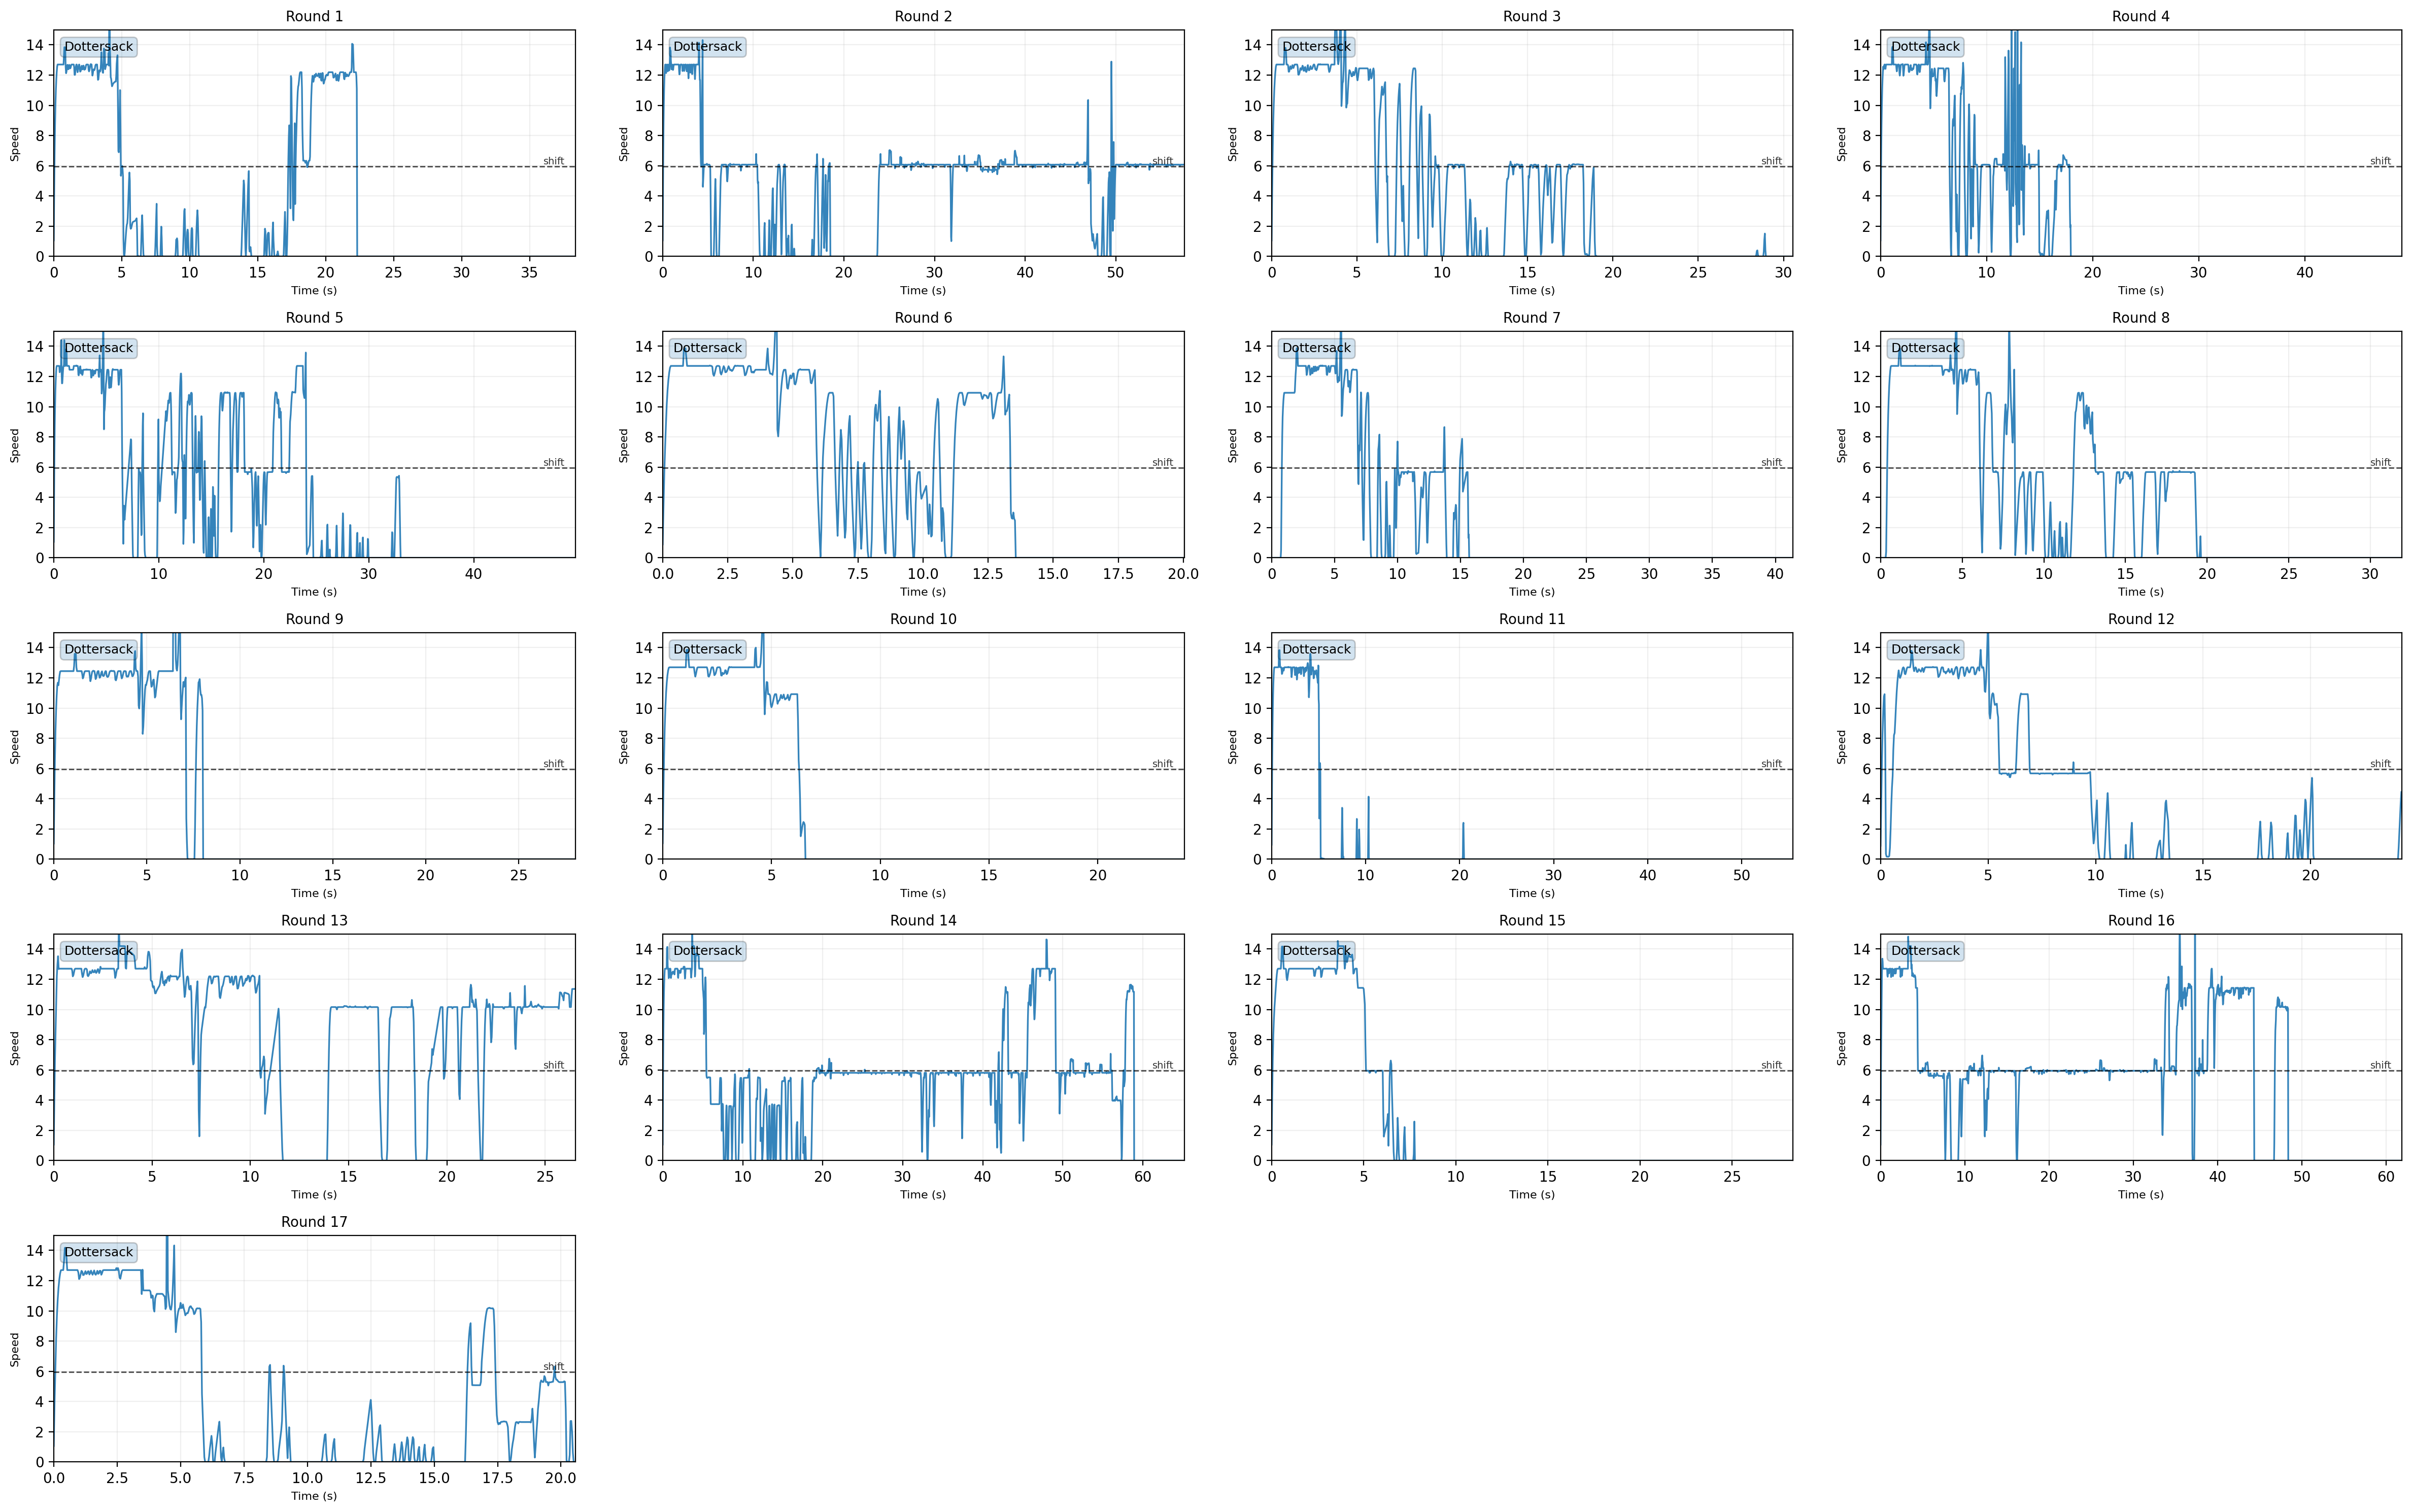

In [ ]:
import matplotlib.pyplot as plt
import math

def plot_speed_per_round(ticks, players, live_round_windows, player_filter=None):
    print("[Plot] Building ROUND-SPLIT curves...")

    # --- OPTIONAL PLAYER FILTER ---
    if player_filter is not None:
        # normalize to list
        if not isinstance(player_filter, list):
            player_filter = [player_filter]

        # detect type (name vs steamid)
        if all(isinstance(p, str) for p in player_filter):
            players = players.filter(pl.col("name").is_in(player_filter))
        else:
            players = players.filter(pl.col("steamid").is_in(player_filter))

        selected_ids = players["steamid"].to_list()
        ticks = ticks.filter(pl.col("steamid").is_in(selected_ids))

        print(f"[Plot] Filtering for players: {players['name'].to_list()}")

    # --- JOIN LIVE WINDOWS ---
    ticks_plot = ticks.join(
        live_round_windows,
        on="round_num",
        how="left"
    )

    # --- ROUND-RELATIVE TIME ---
    ticks_plot = ticks_plot.with_columns([
        ((pl.col("tick") - pl.col("live_start")) / TICKRATE).alias("round_time_sec")
    ])

    # --- VALID GAMEPLAY ---
    ticks_plot = ticks_plot.with_columns([
        (
            (pl.col("tick") >= pl.col("live_start")) &
            (pl.col("tick") <= pl.col("live_end"))
        ).alias("in_live")
    ])

    ticks_plot = ticks_plot.filter(pl.col("in_live"))

    # --- CLEAN SPEED ---
    ticks_plot = ticks_plot.with_columns([
        pl.when(
            (pl.col("dt") == 1) &
            (pl.col("health") > 0)
        )
        .then(pl.col("speed") * 0.0254)
        .otherwise(None)
        .alias("speed_m_s")
    ])

    # --- SMOOTHING ---
    BIN_SIZE = 1/32  # half-tick bins

    ticks_plot = ticks_plot.with_columns([
        (pl.col("round_time_sec") // BIN_SIZE).alias("time_bin")
    ])

    agg = (
        ticks_plot
        .group_by(["round_num", "steamid", "time_bin"])
        .agg(pl.max("speed_m_s").alias("speed_m_s"))
        .sort(["round_num", "steamid", "time_bin"])
    )

    # --- SUBPLOTS SETUP ---
    rounds = agg["round_num"].unique().to_list()
    n_rounds = len(rounds)

    cols = 4
    rows = math.ceil(n_rounds / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 3), dpi=200)
    axes = axes.flatten()

    # --- PLAYER MAP ---
    player_map = {p["steamid"]: p["name"] for p in players.to_dicts()}

    # --- PLOT EACH ROUND ---
    for i, r in enumerate(rounds):
        ax = axes[i]

        df_r = agg.filter(pl.col("round_num") == r)

        # --- STATS (only if multiple players) ---
        if players.height > 1:
            stats = (
                ticks_plot
                .filter(
                    (pl.col("round_num") == r) &
                    (pl.col("health") > 0) &
                    (pl.col("dt") == 1)
                )
                .group_by("steamid")
                .agg(pl.mean("speed_m_s").alias("avg_speed"))
            )

            if stats.height > 0:
                fastest = stats.sort("avg_speed", descending=True).row(0)
                slowest = stats.sort("avg_speed", descending=False).row(0)

                fastest_name = player_map.get(fastest[0], "unknown")
                slowest_name = player_map.get(slowest[0], "unknown")

                label_text = (
                    f"↑ {fastest_name}: {fastest[1]:.1f} m/s\n"
                    f"↓ {slowest_name}: {slowest[1]:.1f} m/s"
                )

                ax.text(
                    0.98, 0.98,
                    label_text,
                    transform=ax.transAxes,
                    fontsize=8,
                    verticalalignment="top",
                    horizontalalignment="right",
                    bbox=dict(boxstyle="round", alpha=0.2)
                )

        # --- PLOT LINES ---
        for p in players.to_dicts():
            sid = p["steamid"]
            name = p["name"]

            df_p = df_r.filter(pl.col("steamid") == sid)

            if df_p.height == 0:
                continue

            time_sec = (df_p["time_bin"] * BIN_SIZE).to_list()
            speed = df_p["speed_m_s"].fill_null(0).to_list()

            ax.plot(time_sec, speed, linewidth=1.2, alpha=0.9, label=name)

        ax.set_title(f"Round {r}", fontsize=10)

        # --- dynamic x-axis ---
        if df_r.height > 0:
            max_bin = df_r["time_bin"].max()
            x_max = min(120, (max_bin * BIN_SIZE) + BIN_SIZE)
            ax.set_xlim(0, x_max)
        else:
            ax.set_xlim(0, 10)

        ax.set_ylim(0, 15)
        ax.set_xlabel("Time (s)", fontsize=8)
        ax.set_ylabel("Speed", fontsize=8)
        ax.grid(alpha=0.2)
        # --- SHIFT SPEED LINE ---
        SHIFT_SPEED = 5.95

        ax.axhline(
            y=SHIFT_SPEED,
            linestyle="--",
            linewidth=1.0,
            alpha=0.7,
            color="black"
        )

        # label (right side of plot)
        ax.text(
            0.98, SHIFT_SPEED,
            "shift",
            transform=ax.get_yaxis_transform(),
            fontsize=7,
            verticalalignment="bottom",
            horizontalalignment="right",
            alpha=0.8
        )

        # --- SINGLE PLAYER LABEL ---
        if players.height == 1:
            ax.text(
                0.02, 0.95,
                players["name"][0],
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment="top",
                bbox=dict(boxstyle="round", alpha=0.2)
            )

    # --- REMOVE UNUSED AXES ---
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# blake: 76561198051680113
# tundra: 76561197987271352
# dotter: 76561198240903150
plot_speed_per_round(ticks_processed, players, live_round_windows, player_filter=76561198240903150)